# 00 · Análisis completo: reglas de asociación sobre Gaming vs Academic Performance

**Proyecto:** Videojuegos y Rendimiento Académico — Ingeniería de Datos, UFRO. Objetivo final: estimar la nota de un estudiante a partir de sus rutinas. Esta entrega define y resuelve un **problema de reglas de asociación** como paso interpretable previo al modelado.

Este notebook contiene el pipeline completo de punta a punta. La misma secuencia está separada en dos partes para lectura por etapas: `01_exploracion_discretizacion.ipynb` y `02_reglas_asociacion.ipynb`.

## Definición del problema

- **Transacción:** un estudiante (fila del dataset limpio).
- **Ítem:** un par `variable=valor`: numéricas por cuartil (`gaming_hours=Q4` = el 25% que más juega), categóricas por su categoría (`stress_level=High`). 13 ítems por transacción, uno por variable.
- **Regla** $X \Rightarrow Y$ con métricas:

$$\mathrm{soporte}(X \Rightarrow Y) = P(X \cup Y) \qquad \mathrm{confianza}(X \Rightarrow Y) = \frac{\mathrm{sop}(X \cup Y)}{\mathrm{sop}(X)} \qquad \mathrm{lift}(X \Rightarrow Y) = \frac{\mathrm{conf}(X \Rightarrow Y)}{\mathrm{sop}(Y)}$$

**Preguntas:**

1. **P1 — minería abierta:** ¿qué patrones globales co-ocurren con más fuerza?, ¿hay variables redundantes entre sí? (insumo para selección de features de la red neuronal).
2. **P2 — foco en notas:** ¿qué combinaciones de hábitos se asocian a cada banda de calificación `grades=Q1…Q4`?

**Algoritmo:** Apriori (`mlxtend`).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# raíz del repo: subir hasta el directorio que contiene data/ (funciona desde la raíz o desde cualquier subcarpeta de notebooks/)
REPO = Path.cwd().resolve()
while not (REPO / 'data').is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
RAW = REPO / 'data' / 'raw' / 'Gaming_Academic_Performance.csv'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

df = pd.read_csv(RAW)
print('Dimensiones crudas:', df.shape)
df.head()

Dimensiones crudas: (8000, 14)


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000


## Limpieza

El dataset no tiene nulos ni duplicados (ver notebook 01), pero `grades` trae valores fuera de escala: notas sobre 100 y una nota 0 (posible abandono o nulo disfrazado). **Decisión del equipo:** eliminar esas filas; el crudo queda intacto en `data/raw/` como respaldo.

In [2]:
print(f'Notas > 100: {(df["grades"] > 100).sum()} (máx {df["grades"].max():.2f})')
print(f'Notas == 0: {(df["grades"] == 0).sum()}')

df_limpio = df[(df['grades'] <= 100) & (df['grades'] > 0)].copy()
print(f'Filas: {len(df)} -> {len(df_limpio)} (eliminadas: {len(df) - len(df_limpio)})')

Notas > 100: 134 (máx 118.63)
Notas == 0: 1
Filas: 8000 -> 7865 (eliminadas: 135)


## Discretización por cuartiles

Apriori trabaja con ítems categóricos: cada numérica se corta en 4 niveles ordenados Q1 < Q2 < Q3 < Q4 (`pd.qcut`). Con distribuciones casi uniformes los bins quedan balanceados (~25% c/u). `student_id` se descarta; las categóricas quedan tal cual. La tabla de rangos permite traducir cada cuartil a valores concretos al leer las reglas.

In [3]:
num_cols = ['age', 'gaming_hours', 'study_hours', 'sleep_hours', 'attendance',
            'social_activity', 'device_usage', 'reaction_time_ms', 'addiction_score', 'grades']
cat_cols = ['gender', 'gaming_genre', 'stress_level']
etiquetas = ['Q1', 'Q2', 'Q3', 'Q4']

df_disc = df_limpio[cat_cols].copy()
cortes = {}
for c in num_cols:
    serie, bins = pd.qcut(df_limpio[c], q=4, retbins=True, duplicates='drop')
    df_disc[c] = serie.cat.rename_categories(etiquetas[:len(bins) - 1])
    cortes[c] = bins

rangos = pd.DataFrame({
    c: {f'Q{i + 1}': f'({cortes[c][i]:.2f}, {cortes[c][i + 1]:.2f}]' for i in range(len(cortes[c]) - 1)}
    for c in num_cols
}).T
rangos

,Q1,Q2,Q3,Q4
age,"(16.00, 18.00]","(18.00, 20.00]","(20.00, 22.00]","(22.00, 24.00]"
gaming_hours,"(0.00, 2.17]","(2.17, 4.17]","(4.17, 6.08]","(6.08, 8.00]"
study_hours,"(1.00, 3.19]","(3.19, 5.38]","(5.38, 7.56]","(7.56, 10.00]"
sleep_hours,"(4.00, 5.23]","(5.23, 6.48]","(6.48, 7.71]","(7.71, 9.00]"
attendance,"(60.00, 69.73]","(69.73, 79.56]","(79.56, 89.99]","(89.99, 100.00]"
social_activity,"(0.00, 1.28]","(1.28, 2.50]","(2.50, 3.76]","(3.76, 5.00]"
device_usage,"(1.10, 5.59]","(5.59, 7.64]","(7.64, 9.61]","(9.61, 13.95]"
reaction_time_ms,"(183.26, 246.87]","(246.87, 270.14]","(270.14, 294.31]","(294.31, 347.87]"
addiction_score,"(-4.51, 5.99]","(5.99, 10.07]","(10.07, 13.90]","(13.90, 23.16]"
grades,"(0.04, 49.51]","(49.51, 66.54]","(66.54, 83.21]","(83.21, 100.00]"


## Itemsets frecuentes

One-hot a matriz booleana transacción × ítem y Apriori con `min_support = 0.05`: un ítem individual soporta ≈ 0.25, un par independiente ≈ 0.0625, así que el umbral retiene los pares y solo deja pasar tríos genuinamente correlacionados (≈ 0.016 bajo independencia). `max_len=4` mantiene los antecedentes interpretables.

In [4]:
onehot = pd.get_dummies(df_disc, prefix_sep='=').astype(bool)
print('Transacciones:', onehot.shape[0], '| ítems posibles:', onehot.shape[1])

frecuentes = apriori(onehot, min_support=0.05, use_colnames=True, max_len=4)
frecuentes['n_items'] = frecuentes['itemsets'].apply(len)
print('Itemsets frecuentes:', len(frecuentes))
print(frecuentes['n_items'].value_counts().sort_index())

Transacciones: 7865 | ítems posibles: 49


Itemsets frecuentes: 1767
n_items
1     48
2    929
3    629
4    161
Name: count, dtype: int64


## P1 · Minería abierta

Todas las reglas con lift ≥ 1.1, ordenadas por lift.

In [5]:
reglas = association_rules(frecuentes, metric='lift', min_threshold=1.1)

def fmt(itemset):
    return ' + '.join(sorted(itemset))

reglas['antecedente'] = reglas['antecedents'].apply(fmt)
reglas['consecuente'] = reglas['consequents'].apply(fmt)
cols = ['antecedente', 'consecuente', 'support', 'confidence', 'lift']

print('Reglas con lift >= 1.1:', len(reglas))
reglas.sort_values('lift', ascending=False)[cols].head(15).round(3)

Reglas con lift >= 1.1: 4808


,antecedente,consecuente,support,confidence,lift
1015,stress_level=High,sleep_hours=Q1 + study_hours=Q4,0.062,0.494,7.961
1014,sleep_hours=Q1 + study_hours=Q4,stress_level=High,0.062,1.000,7.961
4630,grades=Q4 + reaction_time_ms=Q4,gaming_hours=Q1 + study_hours=Q4,0.051,0.441,7.158
4635,gaming_hours=Q1 + study_hours=Q4,grades=Q4 + reaction_time_ms=Q4,0.051,0.823,7.158
4631,gaming_hours=Q1 + grades=Q4,reaction_time_ms=Q4 + study_hours=Q4,0.051,0.418,6.755
4634,reaction_time_ms=Q4 + study_hours=Q4,gaming_hours=Q1 + grades=Q4,0.051,0.819,6.755
4715,grades=Q1 + reaction_time_ms=Q1,gaming_hours=Q4 + study_hours=Q1,0.050,0.385,6.328
4718,gaming_hours=Q4 + study_hours=Q1,grades=Q1 + reaction_time_ms=Q1,0.050,0.826,6.328
4719,gaming_hours=Q4 + grades=Q1,reaction_time_ms=Q1 + study_hours=Q1,0.050,0.366,6.016
4714,reaction_time_ms=Q1 + study_hours=Q1,gaming_hours=Q4 + grades=Q1,0.050,0.825,6.016


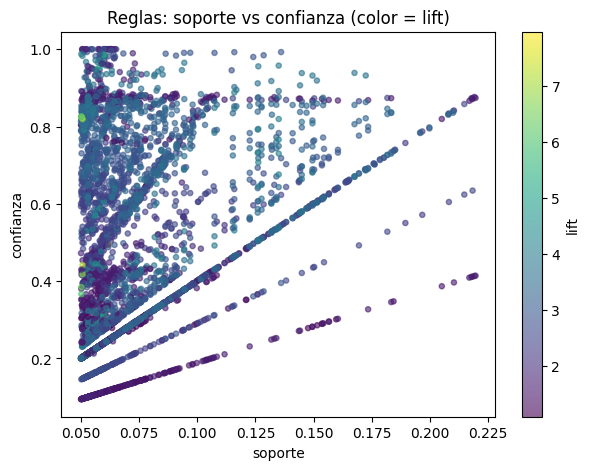

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(reglas['support'], reglas['confidence'], c=reglas['lift'], cmap='viridis', s=14, alpha=0.6)
fig.colorbar(sc, label='lift')
ax.set_xlabel('soporte')
ax.set_ylabel('confianza')
ax.set_title('Reglas: soporte vs confianza (color = lift)')
plt.show()

In [7]:
# P1: redundancia 1-a-1 dentro del cluster de juego detectado en el EDA del equipo (|r| 0.79–0.94)
cluster = {'gaming_hours', 'device_usage', 'addiction_score', 'reaction_time_ms'}

def item_en_cluster(itemset):
    return len(itemset) == 1 and next(iter(itemset)).split('=')[0] in cluster

intra = reglas[reglas['antecedents'].apply(item_en_cluster) & reglas['consequents'].apply(item_en_cluster)]
print('Reglas 1-a-1 dentro del cluster:', len(intra))
intra.sort_values('lift', ascending=False)[cols].head(12).round(3)

Reglas 1-a-1 dentro del cluster: 68


,antecedente,consecuente,support,confidence,lift
69,gaming_hours=Q1,reaction_time_ms=Q4,0.210,0.836,3.343
68,reaction_time_ms=Q4,gaming_hours=Q1,0.210,0.840,3.343
110,reaction_time_ms=Q1,gaming_hours=Q4,0.208,0.831,3.324
111,gaming_hours=Q4,reaction_time_ms=Q1,0.208,0.832,3.324
71,addiction_score=Q1,gaming_hours=Q1,0.200,0.798,3.176
70,gaming_hours=Q1,addiction_score=Q1,0.200,0.795,3.176
113,gaming_hours=Q4,addiction_score=Q4,0.196,0.783,3.138
112,addiction_score=Q4,gaming_hours=Q4,0.196,0.785,3.138
201,addiction_score=Q1,reaction_time_ms=Q4,0.185,0.739,2.956
200,reaction_time_ms=Q4,addiction_score=Q1,0.185,0.740,2.956


## P2 · Reglas hacia bandas de nota

Reglas cuyo consecuente es exactamente una banda de `grades`: qué hábitos co-ocurren con notas bajas (Q1) y altas (Q4).

In [8]:
items_nota = {f'grades=Q{i}' for i in range(1, 5)}
es_nota = reglas['consequents'].apply(lambda s: len(s) == 1 and next(iter(s)) in items_nota)
reglas_nota = reglas[es_nota].copy()
print('Reglas con consecuente = banda de nota:', len(reglas_nota))

for banda in ['grades=Q1', 'grades=Q4']:
    print(f'\n--- {banda} ---')
    sub = reglas_nota[reglas_nota['consecuente'] == banda]
    print(sub.sort_values('lift', ascending=False)[cols].head(8).round(3).to_string(index=False))

Reglas con consecuente = banda de nota: 213

--- grades=Q1 ---
                                            antecedente consecuente  support  confidence  lift
 gaming_hours=Q4 + reaction_time_ms=Q1 + study_hours=Q1   grades=Q1    0.050       0.988 3.948
                       gaming_hours=Q4 + study_hours=Q1   grades=Q1    0.060       0.985 3.940
    gaming_hours=Q4 + stress_level=Low + study_hours=Q1   grades=Q1    0.060       0.985 3.940
 addiction_score=Q4 + stress_level=Low + study_hours=Q1   grades=Q1    0.056       0.971 3.884
reaction_time_ms=Q1 + stress_level=Low + study_hours=Q1   grades=Q1    0.058       0.970 3.880
    device_usage=Q4 + stress_level=Low + study_hours=Q1   grades=Q1    0.052       0.967 3.867
                   reaction_time_ms=Q1 + study_hours=Q1   grades=Q1    0.059       0.967 3.865
                    addiction_score=Q4 + study_hours=Q1   grades=Q1    0.057       0.966 3.861

--- grades=Q4 ---
                                           antecedente consecue

## Conclusiones

1. **Problema definido y resuelto:** 7865 transacciones × 49 ítems; Apriori (soporte ≥ 0.05) produjo 1767 itemsets frecuentes y 4808 reglas con lift ≥ 1.1.
2. **P1 — redundancia estructural:** el cluster `gaming_hours` / `device_usage` / `addiction_score` / `reaction_time_ms` se predice mutuamente (confianza ≈ 0.72–0.84, lift ≈ 2.9–3.3); además `{sleep_hours=Q1 + study_hours=Q4} → stress_level=High` tiene confianza **1.000**, es decir, `stress_level` es función determinista de sueño + estudio (huella del generador sintético). Para la red neuronal: conservar una sola señal del cluster y evaluar excluir `stress_level` por leakage.
3. **P2 — los extremos de estudio y juego casi determinan la banda de nota:** `{gaming=Q4 + study=Q1} → grades=Q1` y su espejo `{gaming=Q1 + study=Q4} → grades=Q4`, ambas con confianza ≈ 0.98 y lift ≈ 3.9. `study_hours` aparece en todas las reglas fuertes; las bandas intermedias (Q2, Q3) solo logran lift ≤ 2.0 — ahí estará el mayor error del modelo de regresión.

**Limitaciones:** dataset sintético (Kaggle) con relaciones casi deterministas; asociación no implica causalidad; la discretización pierde granularidad — la regresión posterior usará los valores continuos.

*(Detalle y discusión extendida en `01_exploracion_discretizacion.ipynb` y `02_reglas_asociacion.ipynb`.)*